# July 2025 Central Texas floods

As evidenced by [this](https://en.wikipedia.org/wiki/July_2025_Central_Texas_floods) Wikipedia article.

This notebook explores data and methodology to identify patterns with regards to this incident.

In [1]:
from datetime import datetime

import duckdb
import contextily as cx
import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import polars as pl
import seaborn as sns

from wpp import data, db

In [2]:
# config
sns.set_theme(style="ticks")
pl.Config.set_engine_affinity("streaming")

con = db.connect()

In [3]:
state_fips = '48'

In [4]:
db.create_block_group_table(state_fips)

In [5]:
db.create_wpp(state_fips)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [6]:
db.create_pois(state_fips)

In [50]:
con.execute(f"""
    CREATE OR REPLACE TABLE wpp AS
    SELECT DISTINCT wpp.*
    FROM wpp_{state_fips} AS wpp
    JOIN bg_{state_fips} AS boundary
      ON boundary.geom && ST_Point(wpp.LONGITUDE, wpp.LATITUDE)
     AND ST_Within(ST_Point(wpp.LONGITUDE, wpp.LATITUDE), boundary.geom)
    WHERE boundary.COUNTYFP = '133'
""")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [52]:
con.execute(f"""
    CREATE OR REPLACE TABLE pois AS
    SELECT DISTINCT p.*
    FROM pois_{state_fips} AS p
    JOIN bg_{state_fips} AS boundary
      ON boundary.geom && ST_Point(p.LONGITUDE, p.LATITUDE)
     AND ST_Within(ST_Point(p.LONGITUDE, p.LATITUDE), boundary.geom)
    WHERE boundary.COUNTYFP = '133'
""")

In [64]:
lf = con.sql(f"""
    SELECT * 
    FROM wpp
    WHERE DATE_RANGE_START BETWEEN '2025-05-01' AND '2025-08-31'
""").pl(lazy=True)
lf.head().collect()

BRAND,BUCKETED_DWELL_TIMES,CITY,CLOSE_DATE,DATE_RANGE_END,DATE_RANGE_START,DEVICE_TYPE,DISTANCE_FROM_HOME,FOOTPRINT_ID,ID_STORE,ISO_COUNTRY_CODE,IS_DISTRIBUTOR,LATITUDE,LOCATION_NAME,LONGITUDE,MEDIAN_DWELL,MSA_CODE,NAICS_CODE,OPEN_DATE,PERSISTENT_ID,PERSISTENT_ID_STORE,POI_CBG,POSTAL_CODE,REGION,RELATED_SAME_DAY_BRAND,RELATED_SAME_WEEK_BRAND,STREET_ADDRESS,SUB_CATEGORY,TICKER,TOP_CATEGORY,VISITOR_COUNTRY_OF_ORIGIN,VISITOR_COUNTS,VISITOR_DAYTIME_CBGS,VISITOR_HOME_AGGREGATION,VISITOR_HOME_CBGS,VISITS_BY_DAY,VISITS_BY_EACH_HOUR,VISIT_COUNTS
str,str,str,date,datetime[μs],datetime[μs],str,f64,"decimal[38,0]",str,str,bool,f64,str,f64,f64,"decimal[38,0]",str,date,str,str,str,str,str,str,str,str,str,str,str,str,"decimal[38,0]",str,str,str,str,str,"decimal[38,0]"
"""All Other Miscellaneous Store …",null,"""Cisco""",2038-01-01,2025-06-01 00:00:00,2025-05-26 00:00:00,null,25141.0,2806618404250475223,"""8563611""","""US""",false,32.388802,"""J T Ranch Quilt Shop LLC""",-98.979973,1.0,null,"""453998""",1970-01-01,"""A1_NAICS-453998""","""8563611""","""481339503013""","""76437""","""TX""","""{""Walmart"":492,""Moneygram"":463…","""{""Convenience Stores"":579,""Dun…","""706 Conrad Hilton Blvd""","""All Other Miscellaneous Store …","""NAICS-453998""","""Other Miscellaneous Store Reta…",null,578,"""{""481339503021"":173,""481339503…","""{""48133950301"":347,""4813395030…","""{""481339503013"":288,""481339503…","""[94,71,82,82,82,83,83]""",null,578
"""Clothing Accessories Stores""","""{""<5"":286, ""5-20"":0, ""21-60"":0…","""Cisco""",2038-01-01,2025-08-03 00:00:00,2025-07-28 00:00:00,"""{""ios"":212,""android"":32}""",4901.0,8418827850460817333,"""8597188""","""US""",false,32.389622,"""Clothing Accessories Stores""",-98.980492,1.0,null,"""448150""",1970-01-01,"""A1_NAICS-448150""","""8597188""","""481339503013""","""76437""","""TX""","""{""Truck Stops"":192,""Cardtronic…","""{""Convenience Stores"":244,""Tru…","""604 Conrad Hilton Blvd""","""Clothing Accessories Stores ""","""NAICS-448150""","""Clothing Stores ""","""{""US"":244}""",244,"""{""481339503022"":122,""481350031…","""{""48133950301"":146,""4813395030…","""{""481339503013"":104,""481339503…","""[23,35,23,35,58,116,12]""","""[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0…",302
"""Moneygram""","""{""<5"":16356, ""5-20"":9023, ""21-…","""Eastland""",2038-01-01,2025-07-20 00:00:00,2025-07-14 00:00:00,"""{""ios"":12642,""android"":11006}""",19053.0,2529453185664901062,"""2044910""","""US""",true,32.404649,"""Moneygram International Inc.""",-98.793056,15.0,null,"""522390""",1970-01-01,"""A1_MGI""","""2044910""","""481339502022""","""76448-3023""","""TX""","""{""Dunlop Tires"":23648,""Walmart…","""{""Dunlop Tires"":23648,""Walmart…","""1410 E Main St""","""Other Activities Related to Cr…","""MGI""","""Activities Related to Credit I…","""{""US"":23648}""",23648,"""{""481339502022"":2932,""48133950…","""{""48133950202"":7888,""481339503…","""{""481339502022"":2783,""48133950…","""[4251,4126,4446,4783,5602,7437…","""[46,138,138,46,46,46,115,206,3…",36578
"""O'Reilly ASE Certified""",null,"""Cisco""",2038-01-01,2025-07-06 00:00:00,2025-06-30 00:00:00,null,null,8820275275716418179,"""6199168""","""US""",false,32.378811,"""O'Reilly ASE Certified""",-98.982349,null,null,"""811111""",1970-01-01,"""A1_ORLYASE-A""","""6199168""","""481339503013""","""76437""","""TX""",null,null,"""711 W.15Th""","""General Automotive Repair ""","""ORLYASE-A""","""Automotive Repair and Maintena…",null,12,null,null,null,"""[12,12,12,12,0,0,0]""",null,47
"""Convenience Stores""","""{""<5"":1970, ""5-20"":117, ""21-60…","""Rising Star""",2038-01-01,2025-07-27 00:00:00,2025-07-21 00:00:00,"""{""android"":1018,""ios"":739}""",43268.0,7785165160575689717,"""12059322""","""US""",false,32.09603,null,-98.965602,4.0,null,"""447110""",1970-01-01,"""A1_CONV-A""","""12059322""","""481339504002""","""76471""","""TX""","""{""Western Union"":1691,""CEFCO C…","""{""Western Union"":1691,""CEFCO C…","""201 W College Street""","""Gasoline Stations with C

<Axes: >

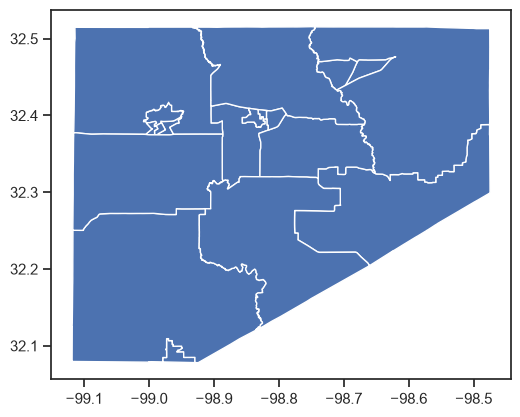

In [65]:
cb_df = con.sql(f"SELECT * FROM bg_{state_fips} WHERE COUNTYFP = '133'").df()
cb_df["geom"] = cb_df["geom"].apply(bytes)
cb = gpd.GeoDataFrame(
    cb_df, 
    geometry=gpd.GeoSeries.from_wkb(cb_df["geom"]), 
    crs="EPSG:4326"
)
cb.plot()

In [66]:
pois = con.sql(f"""
    SELECT *
    FROM pois
""").pl().join(
    lf.group_by("ID_STORE").agg(
        pl.col("VISITOR_COUNTS").sum().cast(pl.Float64),
        pl.col("VISITOR_COUNTS").sum().log().cast(pl.Float64).alias("LOG_VISITOR_COUNTS")
    ).with_columns(
        pl.col("VISITOR_COUNTS")
            .qcut(10, labels=[str(i) for i in range(1, 11)])
            .cast(pl.Utf8).cast(pl.Int64).alias("VISITOR_DECILE")
    ).collect(),
    on="ID_STORE"
)
pois.head()

ID_STORE,BRAND,LOCATION_NAME,STREET_ADDRESS,POI_CBG,CITY,REGION,ISO_COUNTRY_CODE,TOP_CATEGORY,SUB_CATEGORY,OPEN_DATE,CLOSE_DATE,LONGITUDE,LATITUDE,VISITOR_COUNTS,LOG_VISITOR_COUNTS,VISITOR_DECILE
str,str,str,str,str,str,str,str,str,str,date,date,f64,f64,f64,f64,i64
"""11532243""","""EV Charging Stations""","""Electric Vehicle Charging Stat…","""1410 East Main Street""","""481339502022""","""Eastland""","""TX""","""US""","""Gasoline Stations ""","""Other Gasoline Stations """,1970-01-01,2038-01-01,-98.792909,32.403303,18148.0,9.806316,7
"""12003784""","""Convenience Stores""","""ALON - ALLSUPS CONVENIENCE STO…","""913 W 8TH ST""","""481339503014""","""CISCO""","""TX""","""US""","""Gasoline Stations ""","""Gasoline Stations with Conveni…",1970-01-01,2038-01-01,-98.988199,32.383535,14560.0,9.586033,7
"""1520835""","""Aaron's""","""The Aaron's Company, Inc.""","""1405 East Main Street""","""481339502022""","""Eastland""","""TX""","""US""","""Consumer Goods Rental""","""All Other Consumer Goods Renta…",1970-01-01,2038-01-01,-98.793806,32.400634,8057.0,8.994297,5
"""13762120""","""Restaurants""","""Jc's Steakhouse""","""1498 Interstate 20 W""","""481339503014""","""Cisco""","""TX""","""US""","""Restaurants and Other Eating P…","""Full-Service Restaurants """,1970-01-01,2038-01-01,-98.997779,32.376036,23060.0,10.045855,8
"""4840724""","""USPS""","""United States Postal Service""","""526 Fm 3363""","""481339502011""","""Olden""","""TX""","""US""","""Postal Service""","""Postal Service""",1970-01-01,2038-01-01,-98.752719,32.419578,2259.0,7.722678,3


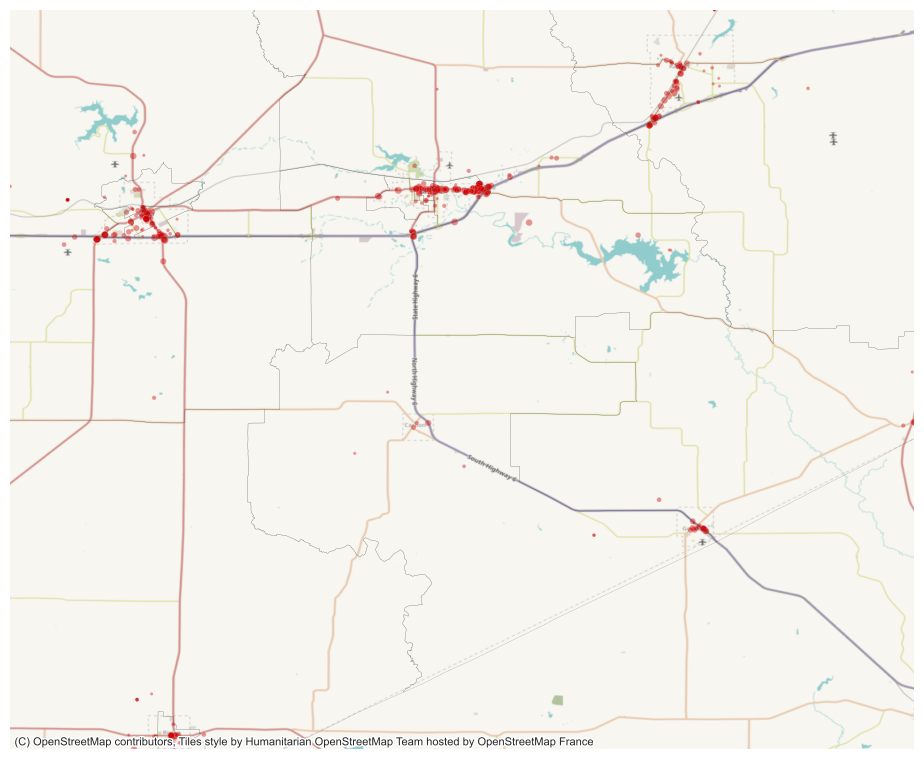

In [58]:
fig_scale = 2
fig, ax = plt.subplots(figsize=(6.4*fig_scale, 4.8*fig_scale))
cb.boundary.plot(ax=ax, color="#444", linewidth=0.1)
sns.scatterplot(
    pois, x="LONGITUDE", y="LATITUDE",
    color="#c00", size="VISITOR_DECILE", sizes=(5, 25),
    alpha=.4, ax=ax, legend=False
)
ax.set_xlim(pois["LONGITUDE"].min(), pois["LONGITUDE"].max())
ax.set_ylim(pois["LATITUDE"].min(), pois["LATITUDE"].max())
cx.add_basemap(ax, crs="EPSG:4326", zoom=12)
ax.set_axis_off()
ax.set_aspect("equal")

In [59]:
visits_by_date = con.sql(f"""
    WITH x AS (
        SELECT 
            DATE_RANGE_START, 
            from_json(VISITS_BY_DAY, '["INTEGER"]')::INTEGER[7] AS VISITS_BY_DAY
        FROM wpp
        WHERE VISITS_BY_DAY IS NOT NULL
          AND DATE_RANGE_START BETWEEN '2025-05-01' AND '2025-08-31'
    ), y AS (
        SELECT
            DATE_RANGE_START::DATE AS DATE,
            unnest(VISITS_BY_DAY) AS VISITS,
            generate_subscripts(VISITS_BY_DAY, 1) AS DAY
        FROM x
    )
    SELECT 
        (DATE + INTERVAL (DAY - 1) DAY)::DATE AS DATE,
        SUM(VISITS) AS VISITS
    FROM y
    GROUP BY 1
    ORDER BY 1
""").pl().with_columns(
    pl.col("VISITS").rolling_mean(window_size=7).alias("VISITS_ROLLING")
)
visits_by_date.head()

DATE,VISITS,VISITS_ROLLING
date,"decimal[38,0]",f64
2025-05-05,127807,null
2025-05-06,119511,null
2025-05-07,127418,null
2025-05-08,132880,null
2025-05-09,158814,null


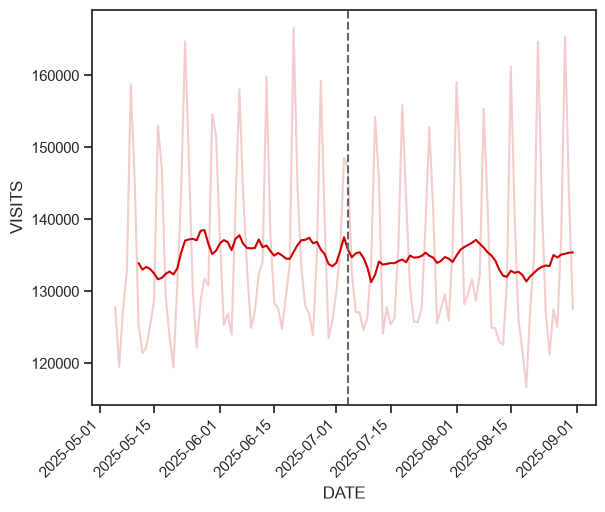

In [60]:
heatwave_date = datetime.fromisoformat("2025-07-04")

x = visits_by_date["DATE"]
y = visits_by_date["VISITS"]
y_r = visits_by_date["VISITS_ROLLING"]

fig, ax = plt.subplots()
sns.lineplot(x=x, y=y, ax=ax, alpha=0.2, color="#c00")
sns.lineplot(x=x, y=y_r, color="#c00", ax=ax)
ax.axvline(heatwave_date, color="#666", linestyle="--")

fig.tight_layout()
ax.tick_params("x", rotation=45, rotation_mode="xtick")

In [69]:
visits_by_date = con.sql(f"""
    WITH x AS (
        SELECT 
            DATE_RANGE_START, 
            COUNTYFP,
            from_json(VISITS_BY_DAY, '["INTEGER"]')::INTEGER[7] AS VISITS_BY_DAY
        FROM wpp
        JOIN bg_{state_fips} ON bg_{state_fips}.GEOID = wpp.POI_CBG
        WHERE VISITS_BY_DAY IS NOT NULL
          AND DATE_RANGE_START BETWEEN '2025-05-01' AND '2025-08-31'
    ), y AS (
        SELECT
            DATE_RANGE_START::DATE AS DATE,
            COUNTYFP,
            unnest(VISITS_BY_DAY) AS VISITS,
            generate_subscripts(VISITS_BY_DAY, 1) AS DAY
        FROM x
    )
    SELECT 
        (DATE + INTERVAL (DAY - 1) DAY)::DATE AS DATE,
        COUNTYFP,
        SUM(VISITS) AS VISITS
    FROM y
    GROUP BY 1, 2
    ORDER BY 1, 2
""").pl().with_columns(
    (pl.col("VISITS") / pl.col("VISITS").mean().over("COUNTYFP")).alias("VISITS_NORMALIZED")
)
visits_by_date.head()

DATE,COUNTYFP,VISITS,VISITS_NORMALIZED
date,str,"decimal[38,0]",f64
2025-05-05,"""133""",127807,0.947593
2025-05-06,"""133""",119511,0.886084
2025-05-07,"""133""",127418,0.944708
2025-05-08,"""133""",132880,0.985205
2025-05-09,"""133""",158814,1.177486


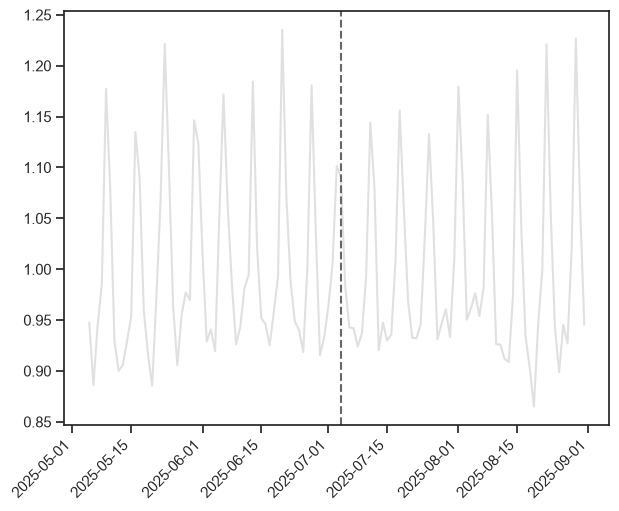

In [70]:
fig, ax = plt.subplots()
for county, group in visits_by_date.group_by("COUNTYFP"):
    color = "#666" if county[0] != "057" else "#c00"
    alpha = 0.2 if county[0] != "057" else 1
    ax.plot(
        group["DATE"],
        group["VISITS_NORMALIZED"],
        color=color,
        alpha=alpha,
    )
ax.axvline(heatwave_date, color="#666", linestyle="--")

fig.tight_layout()
ax.tick_params("x", rotation=45, rotation_mode="xtick")

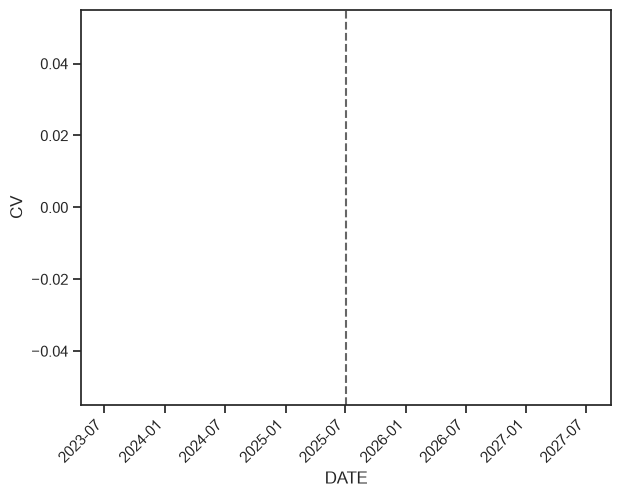

In [71]:
std = visits_by_date.group_by("DATE").agg(
    pl.col("VISITS").std().alias("VISITS_STD"),
    (pl.col("VISITS").std() / pl.col("VISITS").mean()).alias("CV")
)

fig, ax = plt.subplots()
sns.lineplot(
    std,
    x="DATE",
    y="CV",
)
ax.axvline(heatwave_date, color="#666", linestyle="--")

fig.tight_layout()
ax.tick_params("x", rotation=45, rotation_mode="xtick")